In [ ]:
### identify appropriate thresholds for calling a genome present ###
# set up in silico reads
# create strobealign db uhvdb votu reps
# align in silico reads to db
# align hit genomes to input genomes using blast
# load bam into instrain
# identify breadth/expected breadth cutoff that accurately recapitulates input genomes
# identify relationship between depth of coverage and recovery

### compare different tools for analyzing gut virome data ###
# assemble 100 gut virome samples
# create in silico reads from gut virome contigs
# run phanta, baqlava, markermagu, sylph, and uhvdb on in silico reads
# calculate precision/recall for each tool
# calculate predicted richness for each tool

### Create a Kraken2 database

In [ ]:
import polars as pl

# # download inphared metadata
# inphared_meta = pl.read_csv('https://millardlab-inphared.s3.climb.ac.uk/14Apr2025_data.tsv.gz', separator='\t')

# # filter to votu reps
# votu_reps = set(
#     pl.read_csv('/mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb-manuscript/composite_sputum_metagenome/vclust/clusters.txt', has_header=False)
#     ['column_1']
# )

# # create taxonomy tsv for inphared votu reps
# (
#     inphared_meta
#         .filter(pl.col('Accession').is_in(votu_reps))
#         .with_columns([pl.lit(None).alias('Species'), pl.col('Description').alias('S1')])
#         [['Accession', 'Realm', 'Kingdom', 'Phylum', 'Class', 'Order', 'Family', 'Sub-family', 'Genus', 'Species', 'S1']]
#         .write_csv('inphared_votu_reps_taxonomy.tsv', separator='\t', include_header=False)
# )

In [ ]:
%%bash
# taxonkit create-taxdump \
#     inphared_votu_reps_taxonomy.tsv \
#     --out-dir inphared_votu_reps_taxdump/taxonomy \
#     -A 1 \
#     -R R,K,P,C,O,F,F1,G,S,S1

In [ ]:
# (
#     pl.read_csv('inphared_votu_reps_taxdump/taxid.map', has_header=False, separator='\t')
#         .with_columns([
#             (pl.col('column_1') + "|kraken:taxid|" + pl.col('column_2').cast(pl.String)).alias('new_id')
#         ])
#         [['column_1', 'new_id']]
#         .write_csv('inphared_votu_reps_taxdump/acc2k2id.map', separator='\t', include_header=False)
# )

In [ ]:
%%bash
# seqkit replace \
#    ../composite_sputum_metagenome/vclust/14Apr2025_genomes_oral_votu_reps.fa \
#    -p '^(\S+)' \
#    -r '{kv}' \
#    -k inphared_votu_reps_taxdump/acc2k2id.map \
#    -o inphared_votu_reps_taxdump/inphared_votu_reps_kraken2.fna

# # code to build a new kraken2 db
# kraken2-build \
#    --add-to-library inphared_votu_reps_taxdump/inphared_votu_reps_kraken2.fna \
#    --db inphared_votu_reps_taxdump \
#    --threads 32

# kraken2-build \
#    --build \
#    --db inphared_votu_reps_taxdump \
#    --threads 32

# kraken2-inspect \
#    --db inphared_votu_reps_taxdump \
#    > inphared_votu_reps_taxdump/k2_minimizer_counts.txt

# k2 classify \
#    ../composite_sputum_metagenome/oral_phage_readsim/split_0_reads_R1.fastq.gz \
#    ../composite_sputum_metagenome/oral_phage_readsim/split_0_reads_R2.fastq.gz \
#    --db /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb-manuscript/figure_s10/inphared_votu_reps_taxdump \
#    --threads 32 \
#    --output TEST.tsv \
#    --report TEST.report \
#    --report-minimizer-data \
#    --paired

# est_abundance.py \
#    -i TEST.report \
#    -k k2_viral_refseq/database300mers.kmer_distrib \
#    -l S \
#    -t 3 \
#    -o TEST.bracken

### Test sylph/align using inphared as reference

In [ ]:
# strobealign
!coverm contig \
    --coupled ../composite_sputum_metagenome/oral_phage_readsim/split_0_reads_R1.fastq.gz \
    ../composite_sputum_metagenome/oral_phage_readsim/split_0_reads_R2.fastq.gz \
    --reference ../composite_sputum_metagenome/vclust/14Apr2025_genomes_oral_votu_reps.fa \
    --mapper strobealign \
    --methods trimmed_mean mean covered_bases length \
    --output-file inphared_test/split_0/split_0_strobealign.tsv \
    --threads 32

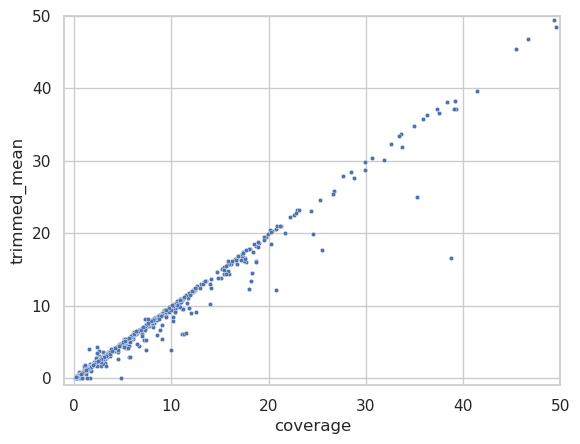

In [313]:
import polars as pl
import math

df_lst = []

for i in range(0,1):
    if i < 5:
            j = i + 1
    else:
        j = (i % 5) + 1

    # read coverage file
    inphared_meta = pl.read_csv(f'../figure_s9/composite_sputum/split_{j}/split_{i}_cov.txt', separator='\t')

    # load instrain scaffold info files
    coverm = (
        pl.read_csv(f'inphared_test/split_{i}/split_{i}_strobealign.tsv', separator='\t', new_columns=['contig_id', 'trimmed_mean', 'mean_coverage', 'covered_bases', 'length'])
            .with_columns([
                (pl.col('covered_bases') / pl.col('length')).alias('breadth'),
            ])
            .with_columns([
                (1 - math.e**(-0.833 * pl.col('mean_coverage'))).alias('expected_breadth'),
            ])
            .with_columns([
                (pl.col('breadth')/pl.col('expected_breadth')).alias('breadth_ratio'),
            ])
            .filter(pl.col('breadth_ratio') >= 0.85)
    )

    df_lst.append(inphared_meta.join(coverm, left_on='tname', right_on='contig_id', how='left')[['tname', 'coverage', 'genome_length', 'trimmed_mean', 'mean_coverage', 'breadth']])

# create dataframe
df = pl.concat(df_lst).fill_null(0)
# plot breadth results
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")
sns.scatterplot(data=df, x='coverage', y='trimmed_mean', s=10, alpha=1)
plt.xlim(-1,50)
plt.ylim(-1,50)
plt.show()

In [ ]:
# sylph profile + strobealign
# !sylph sketch \
#     --genomes ../composite_sputum_metagenome/vclust/14Apr2025_genomes_oral_votu_reps.fa \
#     -t 32 \
#     --individual-records \
#     --out-name-db inphared_test/inphared.votu_reps.c100 \
#     -c 100

# !sylph profile \
#     inphared_test/inphared.votu_reps.c100.syldb \
#     -1 ../composite_sputum_metagenome/oral_phage_readsim/split_0_reads_R1.fastq.gz \
#     -2 ../composite_sputum_metagenome/oral_phage_readsim/split_0_reads_R2.fastq.gz \
#     --output-file inphared_test/split_0/split_0_profile.profile.tsv \
#     -t 32 \
#     -c 100

# load sylph query to identify contained species
(
    pl.read_csv('inphared_test/split_0/split_0_profile.profile.tsv', separator='\t', ignore_errors=True)
        .with_columns([
            pl.col('Contig_name').str.split(' ').list[0].alias('contig_id')
        ])
        [['contig_id']]
        .write_csv('inphared_test/split_0/split_0_profile.top_per_votu.txt', separator='\t', include_header=False)
)

# !seqkit grep \
#     ../composite_sputum_metagenome/vclust/14Apr2025_genomes_oral_votu_reps.fa \
#     --pattern-file inphared_test/split_0/split_0_profile.top_per_votu.txt \
#     -o inphared_test/split_0/split_0_profile.top_per_votu.fna

# !coverm contig \
#     --coupled ../composite_sputum_metagenome/oral_phage_readsim/split_0_reads_R1.fastq.gz \
#     ../composite_sputum_metagenome/oral_phage_readsim/split_0_reads_R2.fastq.gz \
#     --reference inphared_test/split_0/split_0_profile.top_per_votu.fna \
#     --mapper strobealign \
#     --methods trimmed_mean mean covered_bases length \
#     --output-file inphared_test/split_0/split_0_profile.tsv \
#     --threads 32

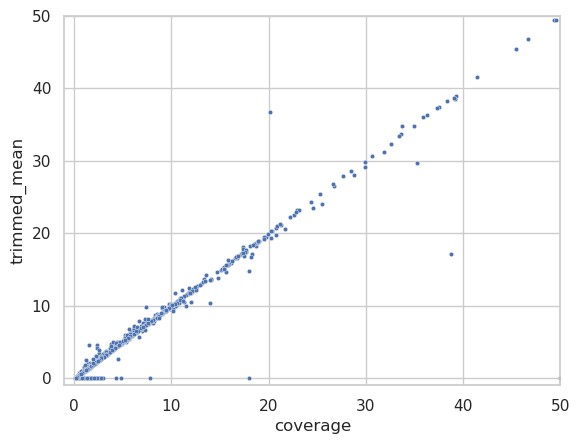

In [316]:
import polars as pl
import math

df_lst = []

for i in range(0,1):
    if i < 5:
            j = i + 1
    else:
        j = (i % 5) + 1

    # read coverage file
    inphared_meta = pl.read_csv(f'../figure_s9/composite_sputum/split_{j}/split_{i}_cov.txt', separator='\t')

    # load instrain scaffold info files
    coverm = (
        pl.read_csv(f'inphared_test/split_{i}/split_{i}_profile.tsv', separator='\t', new_columns=['contig_id', 'trimmed_mean', 'mean_coverage', 'covered_bases', 'length'])
            .with_columns([
                (pl.col('covered_bases') / pl.col('length')).alias('breadth'),
            ])
            .with_columns([
                (1 - math.e**(-0.833 * pl.col('mean_coverage'))).alias('expected_breadth'),
            ])
            .with_columns([
                (pl.col('breadth')/pl.col('expected_breadth')).alias('breadth_ratio'),
            ])
            .filter(pl.col('breadth_ratio') >= 0.85)
    )

    df_lst.append(inphared_meta.join(coverm, left_on='tname', right_on='contig_id', how='left')[['tname', 'coverage', 'genome_length', 'trimmed_mean', 'mean_coverage', 'breadth']])

# create dataframe
df = pl.concat(df_lst).fill_null(0)
# plot breadth results
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")
sns.scatterplot(data=df, x='coverage', y='trimmed_mean', s=10, alpha=1)
plt.xlim(-1,50)
plt.ylim(-1,50)
plt.show()

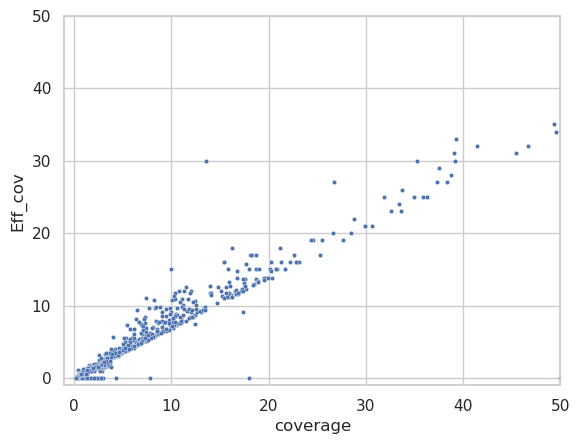

In [413]:
# sylph profile only
import polars as pl
import math

df_lst = []

for i in range(0,1):
    if i < 5:
            j = i + 1
    else:
        j = (i % 5) + 1

    # read coverage file
    inphared_meta = pl.read_csv(f'../figure_s9/composite_sputum/split_{j}/split_{i}_cov.txt', separator='\t')

    # load coverm data
    coverm = (
        pl.read_csv(f'inphared_test/split_{i}/split_{i}_profile.profile.tsv', separator='\t', ignore_errors=True)
            .with_columns([
                pl.col('Contig_name').str.split(' ').list[0].alias('contig_id')
            ])
    )

    df_lst.append(inphared_meta.join(coverm, left_on='tname', right_on='contig_id', how='left')[['tname', 'coverage', 'genome_length', 'Eff_cov']])

# create dataframe
df = pl.concat(df_lst).fill_null(0)
# plot breadth results
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")
sns.scatterplot(data=df, x='coverage', y='Eff_cov', s=10, alpha=1)
plt.xlim(-1,50)
plt.ylim(-1,50)
plt.show()

### Test sylph using UHVDB as reference

In [ ]:
# # strobealign

# !coverm contig \
#     --coupled ../composite_sputum_metagenome/oral_phage_readsim/split_0_reads_R1.fastq.gz \
#     ../composite_sputum_metagenome/oral_phage_readsim/split_0_reads_R2.fastq.gz \
#     --reference uhvdb.votu_reps.fna \
#     --mapper strobealign \
#     --methods trimmed_mean mean covered_bases length \
#     --min-read-percent-identity 92 \
#     --output-file uhvdb_test/split_0/split_0_strobealign.tsv \
#     --threads 32

# load sylph query to identify contained species
(
    pl.read_csv('uhvdb_test/split_0/split_0_strobealign.tsv', separator='\t', ignore_errors=True)
        .with_columns([
            pl.col('Contig').str.split(' ').list[0].alias('contig_id')
        ])
        .filter(pl.col('uhvdb.votu_reps.fna/split_0_reads_R1.fastq.gz Covered Bases') > 1000)
        [['contig_id']]
        .write_csv('uhvdb_test/split_0/split_0_strobealign.hits.txt', separator='\t', include_header=False)
)

# !seqkit grep \
#     uhvdb.votu_reps.fna \
#     --pattern-file uhvdb_test/split_0/split_0_strobealign.hits.txt \
#     -o uhvdb_test/split_0/split_0_strobealign.hits.fna

# # align potentially detected to input genomes
# !micromamba run -n blast \
#     blastn \
#     -query uhvdb.votu_reps.fna \
#     -db ../composite_sputum_metagenome/oral_votu_reps_split/14Apr2025_genomes_oral_votu_reps.part_001.blastdb \
#     -outfmt '6  std qlen slen' \
#     -max_target_seqs 4000 \
#     -out uhvdb_test/uhvdb.votu_reps_v_input.blastn.tsv \
#     -num_threads 32

# !micromamba run -n blast python /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb-manuscript/figure_s9/composite_sputum/anicalc.py \
#     -i uhvdb_test/uhvdb.votu_reps_v_input.blastn.tsv \
#     -o uhvdb_test/uhvdb.votu_reps_v_input.anicalc.tsv

TP species: 43
TP genera: 19
FP: 0
Total species > 1x: 98
Total genera > 1x: 1856


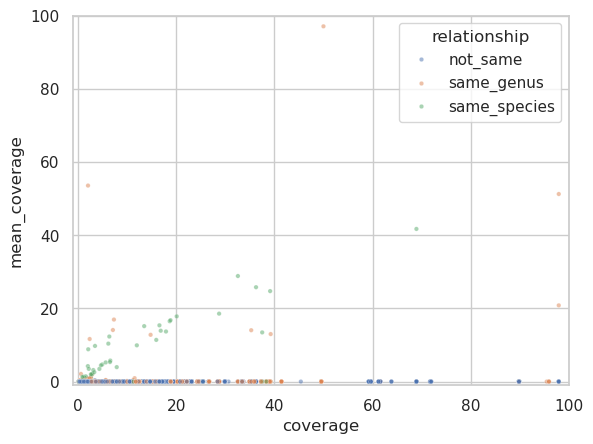

In [275]:
import polars as pl
import math

df_lst = []

for i in range(0,1):
    if i < 5:
            j = i + 1
    else:
        j = (i % 5) + 1

    # read coverage file
    inphared_meta = pl.read_csv(f'../figure_s9/composite_sputum/split_{j}/split_{i}_cov.txt', separator='\t')

    # load coverm data
    coverm = (
        pl.read_csv(f'uhvdb_test/split_{i}/split_{i}_strobealign.tsv', separator='\t', ignore_errors=True, new_columns=['contig_id', 'trimmed_mean', 'mean_coverage', 'covered_bases', 'length'])
            .with_columns([
                (pl.col('covered_bases') / pl.col('length')).alias('breadth'),
            ])
            .with_columns([
                (pl.col('covered_bases') / pl.col('length')).alias('breadth'),
            ])
            .with_columns([
                (1 - math.e**(-0.833 * pl.col('mean_coverage'))).alias('expected_breadth'),
            ])
            .with_columns([
                (pl.col('breadth')/pl.col('expected_breadth')).alias('breadth_ratio'),
            ])
            .filter(pl.col('breadth_ratio') >= 0.85)
    )

    # identify coverm genomes that are in inphared meta
    anicalc = (
        pl.read_csv(f'uhvdb_test/uhvdb.votu_reps_v_input.anicalc.tsv', separator='\t')
            .with_columns([
                ((pl.col('pid') * (pl.col('qcov')))/10000).alias('qani'),
                ((pl.col('pid') * (pl.col('tcov')))/10000).alias('tani')
            ])
            .with_columns([
                pl.when((pl.col('pid') >= 95) & ((pl.col('qcov') >= 85) | (pl.col('tcov') >= 85))).then(pl.lit('same_species'))
                    .when((pl.col('qani') >= 0.6) | (pl.col('tani') >= 0.6)).then(pl.lit('same_genus'))
                    .otherwise(pl.lit('not_same'))
                    .alias('relationship'),
            ])
            .join(inphared_meta, on='tname', how='right') # only keep blast results if the target is in the input genomes
            .sort('qani', descending=True)
            .group_by('qname', maintain_order=True)
            .first()
            .join(coverm, left_on='qname', right_on='contig_id', how='full')
    )

    df_lst.append(anicalc[['qname', 'tname', 'pid', 'qcov', 'tcov', 'qani', 'relationship', 'coverage', 'genome_length', 'trimmed_mean', 'mean_coverage', 'breadth', 'breadth_ratio']])

# create dataframe
df = pl.concat(df_lst).fill_null(0)
print("TP species:", df.filter((pl.col('relationship') == 'same_species') & (pl.col('breadth_ratio') >= 0.85) & (pl.col('mean_coverage') > 0.5)).shape[0])
print("TP genera:", df.filter((pl.col('relationship') == 'same_genus') & (pl.col('breadth_ratio') >= 0.85) & (pl.col('mean_coverage') > 0.5)).shape[0])
print("FP:", df.filter((pl.col('relationship') == 'not_same') & (pl.col('breadth_ratio') >= 0.85) & (pl.col('mean_coverage') > 0.5)).shape[0])
print("Total species > 1x:", df.filter((pl.col('relationship') == 'same_species') & (pl.col('coverage') >= 1)).shape[0])
print("Total genera > 1x:", df.filter((pl.col('relationship') == 'same_genus') & (pl.col('coverage') >= 1)).shape[0])
# plot breadth results
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")
sns.scatterplot(data=df, x='coverage', y='mean_coverage', s=10, alpha=0.5, hue='relationship')
plt.xlim(-1, 100)
plt.ylim(-1, 100)
plt.show()

In [ ]:
# sylph query + strobealigns

# !sylph sketch \
#     --genomes uhvdb.votu_reps.fna \
#     -t 32 \
#     --individual-records \
#     --out-name-db uhvdb_test/uhvdb.votu_reps.c100 \
#     -c 100

# !sylph query \
#     uhvdb_test/uhvdb.votu_reps.c100.syldb \
#     -1 ../composite_sputum_metagenome/oral_phage_readsim/split_20_reads_R1.fastq.gz \
#     -2 ../composite_sputum_metagenome/oral_phage_readsim/split_20_reads_R2.fastq.gz \
#     --output-file uhvdb_test/split_20/split_20_query.query.tsv \
#     -t 4 \
#     -c 100

# load sylph query to identify contained species
(
    pl.read_csv('uhvdb_test/split_20/split_20_query.query.tsv', separator='\t', ignore_errors=True)
        .filter(pl.col('Adjusted_ANI') >= 97)
        .with_columns([
            pl.col('Contig_name').str.split(' ').list[0].alias('contig_id')
        ])
        [['contig_id']]
        .write_csv('uhvdb_test/split_20/split_20_query.top_per_votu.txt', separator='\t', include_header=False)
)

!seqkit grep \
    uhvdb.votu_reps.fna \
    --pattern-file uhvdb_test/split_20/split_20_query.top_per_votu.txt | \
seqkit rmdup \
    -o uhvdb_test/split_20/split_20_query.top_per_votu.fna

!coverm contig \
    --coupled ../composite_sputum_metagenome/oral_phage_readsim/split_20_reads_R1.fastq.gz \
    ../composite_sputum_metagenome/oral_phage_readsim/split_20_reads_R2.fastq.gz \
    --reference uhvdb_test/split_20/split_20_query.top_per_votu.fna \
    --mapper strobealign \
    --bam-file-cache-directory uhvdb_test/split_20/bams \
    --methods trimmed_mean mean covered_bases length \
    --min-read-percent-identity 92 \
    --min-read-aligned-percent 100 \
    --output-file uhvdb_test/split_20/split_20_query.tsv \
    --threads 32

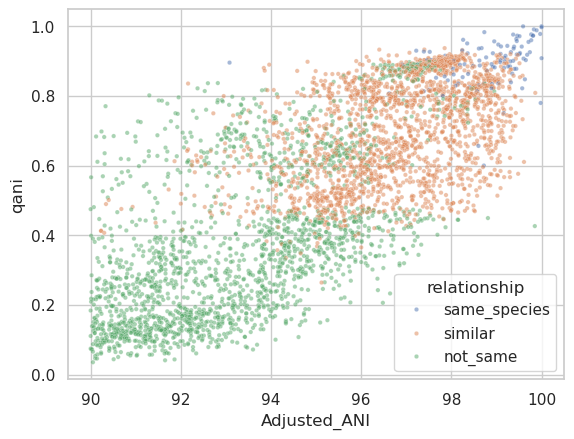

Number TP: 104
Number FP: 3874


In [311]:
# plot query containment ani vs same species via anicalc

anicalc = (
    pl.read_csv(f'uhvdb_test/uhvdb.votu_reps_v_input.anicalc.tsv', separator='\t')
    .join(
        pl.read_csv('uhvdb_test/split_0/split_0_query.query.tsv', separator='\t', ignore_errors=True)
            .with_columns([
                pl.col('Contig_name').str.split(' ').list[0].alias('contig_id')
            ]),
        left_on='qname',
        right_on='contig_id',
        how='inner'
    )
    .with_columns([
        ((pl.col('pid') * (pl.col('qcov')))/10000).alias('qani'),
        ((pl.col('pid') * (pl.col('tcov')))/10000).alias('tani')
    ])
    .with_columns([
        pl.when((pl.col('pid') >= 95) & ((pl.col('qcov') >= 85) | (pl.col('tcov') >= 85))).then(pl.lit('same_species'))
            .when((pl.col('pid') >= 90) & ((pl.col('qcov') >= 50) | (pl.col('tcov') >= 50))).then(pl.lit('similar'))
            .otherwise(pl.lit('not_same'))
            .alias('relationship'),
    ])
    .sort('qani', descending=True)
    .group_by('qname', maintain_order=True)
    .first()
)

# scatterplot
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")
sns.scatterplot(data=anicalc, x='Adjusted_ANI', y='qani', s=10, alpha=0.5, hue='relationship')
plt.show()

print("Number TP:", anicalc.filter((pl.col('Adjusted_ANI') > 90) & (pl.col('relationship') == 'same_species')).shape[0])
print("Number FP:", anicalc.filter((pl.col('Adjusted_ANI') > 90) & (pl.col('relationship') != 'same_species')).shape[0])

TP species: 53
TP genera: 18
FP: 0
R-squared: 0.7376919737198755
Total species > 1x: 99
Total genera > 1x: 348


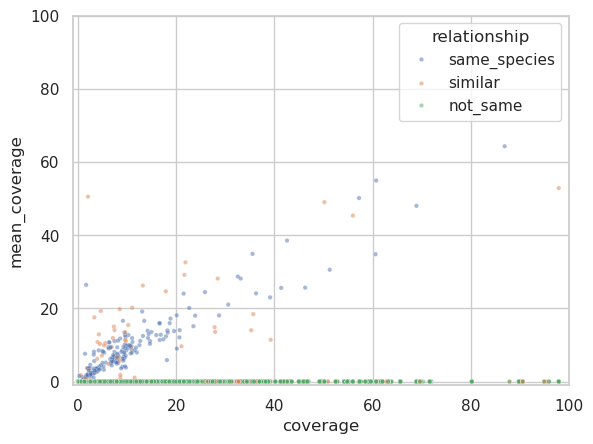

In [45]:
# sylph query
import polars as pl
import math
from sklearn.metrics import r2_score

df_lst = []

for i in [0,5,10,15,20]:
    if i < 5:
            j = i + 1
    else:
        j = (i % 5) + 1

    # read coverage file
    inphared_meta = pl.read_csv(f'../figure_s9/composite_sputum/split_{j}/split_{i}_cov.txt', separator='\t')

    # load coverm data
    coverm = (
        pl.read_csv(f'uhvdb_test/split_{i}/split_{i}_query.tsv', separator='\t', ignore_errors=True, new_columns=['contig_id', 'trimmed_mean', 'mean_coverage', 'covered_bases', 'length'])
            .with_columns([
                (pl.col('covered_bases') / pl.col('length')).alias('breadth'),
            ])
            .with_columns([
                (pl.col('covered_bases') / pl.col('length')).alias('breadth'),
            ])
            .with_columns([
                (1 - math.e**(-0.833 * pl.col('mean_coverage'))).alias('expected_breadth'),
            ])
            .with_columns([
                (pl.col('breadth')/pl.col('expected_breadth')).alias('breadth_ratio'),
            ])
            .filter((pl.col('breadth_ratio') >= 0.85) & (pl.col('breadth') >= 0.5))
    )

    # identify coverm genomes that are in inphared meta
    anicalc = (
        pl.read_csv(f'uhvdb_test/uhvdb.votu_reps_v_input.anicalc.tsv', separator='\t')
            .with_columns([
                ((pl.col('pid') * (pl.col('qcov')))/10000).alias('qani'),
                ((pl.col('pid') * (pl.col('tcov')))/10000).alias('tani')
            ])
            .with_columns([
                pl.when((pl.col('pid') >= 95) & ((pl.col('qcov') >= 85) | (pl.col('tcov') >= 85))).then(pl.lit('same_species'))
                    .when((pl.col('pid') >= 90) & ((pl.col('qcov') >= 50) | (pl.col('tcov') >= 50))).then(pl.lit('similar'))
                    .otherwise(pl.lit('not_same'))
                    .alias('relationship'),
            ])
            .join(inphared_meta, on='tname', how='right') # only keep blast results if the target is in the input genomes
            .sort('qani', descending=True)
            .group_by('qname', maintain_order=True)
            .first()
            .join(coverm, left_on='qname', right_on='contig_id', how='full')
    )

    df_lst.append(anicalc[['qname', 'tname', 'pid', 'qcov', 'tcov', 'qani', 'relationship', 'coverage', 'genome_length', 'trimmed_mean', 'mean_coverage', 'breadth', 'breadth_ratio']])

# create dataframe
df = pl.concat(df_lst).fill_null(0)
print("TP species:", df.filter((pl.col('relationship') == 'same_species') & (pl.col('breadth_ratio') >= 0.85) & (pl.col('breadth') >= 0.5)).unique('tname').shape[0])
print("TP genera:", df.filter((pl.col('relationship') == 'similar') & (pl.col('breadth_ratio') >= 0.85) & (pl.col('breadth') >= 0.5)).unique('tname').shape[0])
print("FP:", df.filter((pl.col('relationship') == 'not_same') & (pl.col('breadth_ratio') >= 0.85) & (pl.col('breadth') >= 0.5)).unique('tname').shape[0])
print("R-squared:", r2_score(df.filter((pl.col('coverage') > 0) & (pl.col('breadth_ratio') >= 0.85) & (pl.col('breadth') >= 0.5))['coverage'].to_list(), df.filter((pl.col('coverage') > 0) & (pl.col('breadth_ratio') >= 0.85) & (pl.col('breadth') >= 0.5))['mean_coverage'].to_list()))
print("Total species > 1x:", df.filter((pl.col('relationship') == 'same_species') & (pl.col('coverage') > 0)).unique('tname').shape[0])
print("Total genera > 1x:", df.filter((pl.col('relationship') == 'similar') & (pl.col('coverage') > 0)).unique('tname').shape[0])
# plot breadth results
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")
sns.scatterplot(data=df, x='coverage', y='mean_coverage', s=10, alpha=0.5, hue='relationship')
plt.xlim(-1, 100)
plt.ylim(-1, 100)
plt.show()

In [ ]:
sourmash scripts manysketch /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb-manuscript/figure_s10/sourmash_manysketch_uhvdb_genomovars -p dna,k=31,scaled=200 --singleton -o uhvb.genomovars.sc200.sig.zip

sourmash scripts manysketch /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb-manuscript/figure_s10/sourmash_manysketch_fastq -p dna,k=31,scaled=200,abund -o split_0.sc200.sig.zip

sourmash scripts fastgather split_0.sc200.sig.zip uhvb.genomovars.sc200.sig.zip -t 1000 -o split_0_vs_uhvdb.genomovars.sc200.csv

In [ ]:
# sylph profile + strobealigns

# !sylph sketch \
#     --genomes uhvdb.votu_reps.fna \
#     -t 32 \
#     --individual-records \
#     --out-name-db uhvdb_test/uhvdb.votu_reps.c100 \
#     -c 100

# !sylph profile \
#     uhvdb_test/uhvdb.votu_reps.c100.syldb \
#     -1 ../composite_sputum_metagenome/oral_phage_readsim/split_20_reads_R1.fastq.gz \
#     -2 ../composite_sputum_metagenome/oral_phage_readsim/split_20_reads_R2.fastq.gz \
#     --output-file uhvdb_test/split_20/split_20_profile.profile.tsv \
#     -t 32 \
#     -c 100

import polars as pl
# load sylph profile to identify contained species
(
    pl.read_csv('uhvdb_test/split_20/split_20_profile.profile.tsv', separator='\t', ignore_errors=True)
        .with_columns([
            pl.col('Contig_name').str.split(' ').list[0].alias('contig_id')
        ])
        .filter(pl.col('Adjusted_ANI') >= 95)
        [['contig_id']]
        .write_csv('uhvdb_test/split_20/split_20_profile.top_per_votu.txt', separator='\t', include_header=False)
)

!seqkit grep \
    uhvdb.votu_reps.fna \
    --pattern-file uhvdb_test/split_15/split_15_profile.top_per_votu.txt | \
seqkit rmdup \
    -o uhvdb_test/split_15/split_15_profile.top_per_votu.fna

!coverm contig \
    --coupled ../composite_sputum_metagenome/oral_phage_readsim/split_15_reads_R1.fastq.gz \
    ../composite_sputum_metagenome/oral_phage_readsim/split_15_reads_R2.fastq.gz \
    --reference uhvdb_test/split_15/split_15_profile.top_per_votu.fna \
    --mapper strobealign \
    --bam-file-cache-directory uhvdb_test/split_15/bams \
    --min-read-percent-identity 95 \
    --min-read-aligned-percent 100 \
    --methods trimmed_mean mean covered_bases length \
    --output-file uhvdb_test/split_15/split_15_profile.tsv \
    --threads 32

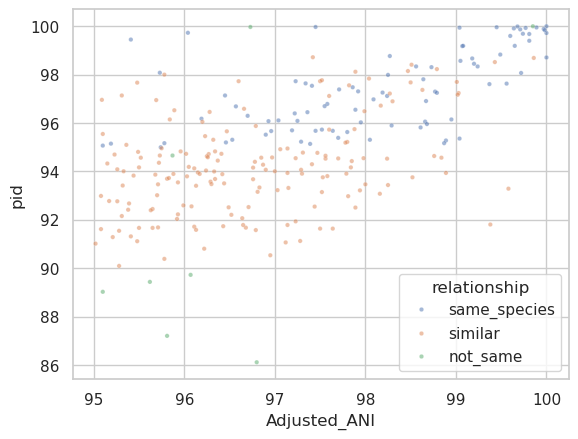

Number TP: 86
Number FP: 176


In [69]:
# plot query containment ani vs same species via anicalc

anicalc = (
    pl.read_csv(f'uhvdb_test/uhvdb.votu_reps_v_input.anicalc.tsv', separator='\t')
    .join(
        pl.read_csv('uhvdb_test/split_0/split_0_profile.profile.tsv', separator='\t', ignore_errors=True)
            .with_columns([
                pl.col('Contig_name').str.split(' ').list[0].alias('contig_id')
            ]),
        left_on='qname',
        right_on='contig_id',
        how='inner'
    )
    .with_columns([
        ((pl.col('pid') * (pl.col('qcov')))/10000).alias('qani'),
        ((pl.col('pid') * (pl.col('tcov')))/10000).alias('tani')
    ])
    .with_columns([
        pl.when((pl.col('pid') >= 95) & ((pl.col('qcov') >= 85) | (pl.col('tcov') >= 85))).then(pl.lit('same_species'))
            .when((pl.col('pid') >= 90) & ((pl.col('qcov') >= 50) | (pl.col('tcov') >= 50))).then(pl.lit('similar'))
            .otherwise(pl.lit('not_same'))
            .alias('relationship'),
    ])
    .sort('qani', descending=True)
    .group_by('qname', maintain_order=True)
    .first()
)

# scatterplot
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")
sns.scatterplot(data=anicalc, x='Adjusted_ANI', y='pid', s=10, alpha=0.5, hue='relationship')
plt.show()

print("Number TP:", anicalc.filter((pl.col('Adjusted_ANI') > 90) & (pl.col('relationship') == 'same_species')).shape[0])
print("Number FP:", anicalc.filter((pl.col('Adjusted_ANI') > 90) & (pl.col('relationship') != 'same_species')).shape[0])

TP species: 59
TP genera: 24
FP: 0
R-squared: 0.7367718586011434
Total species > 1x: 99
Total genera > 1x: 348


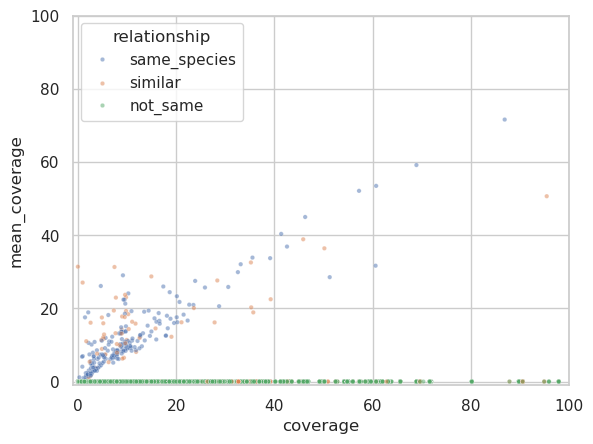

In [49]:
# use normal breadth > 0.85
import polars as pl
import math

df_lst = []

for i in [0,5,10,15,20]:
    if i < 5:
            j = i + 1
    else:
        j = (i % 5) +1

    # read coverage file
    inphared_meta = pl.read_csv(f'../figure_s9/composite_sputum/split_{j}/split_{i}_cov.txt', separator='\t')

    # load coverm data
    coverm = (
        pl.read_csv(f'uhvdb_test/split_{i}/split_{i}_profile.tsv', separator='\t', ignore_errors=True, new_columns=['contig_id', 'trimmed_mean', 'mean_coverage', 'covered_bases', 'length'])
            .join(
                pl.read_csv(f'uhvdb_test/split_{i}/split_{i}_profile.profile.tsv', separator='\t', ignore_errors=True)
                .with_columns([
                    pl.col('Contig_name').str.split(' ').list[0].alias('contig_id')
                ]),
                on='contig_id', how='inner'
            )
            .with_columns([
                (pl.col('covered_bases') / pl.col('length')).alias('breadth'),
            ])
            .with_columns([
                (pl.col('covered_bases') / pl.col('length')).alias('breadth'),
            ])
            .with_columns([
                (1 - math.e**(-0.833 * pl.col('mean_coverage'))).alias('expected_breadth'),
            ])
            .with_columns([
                (pl.col('breadth')/pl.col('expected_breadth')).alias('breadth_ratio'),
            ])
            .filter((pl.col('breadth_ratio') >= 0.85) & (pl.col('breadth') >= 0.5) & (pl.col('Adjusted_ANI') >= 97))
    )

    # identify coverm genomes that are in inphared meta
    anicalc = (
        pl.read_csv(f'uhvdb_test/uhvdb.votu_reps_v_input.anicalc.tsv', separator='\t')
            .with_columns([
                ((pl.col('pid') * (pl.col('qcov')))/10000).alias('qani'),
                ((pl.col('pid') * (pl.col('tcov')))/10000).alias('tani')
            ])
            .with_columns([
                pl.when((pl.col('pid') >= 95) & ((pl.col('qcov') >= 85) | (pl.col('tcov') >= 85))).then(pl.lit('same_species'))
                    .when((pl.col('pid') >= 90) & ((pl.col('qcov') >= 50) | (pl.col('tcov') >= 50))).then(pl.lit('similar'))
                    .otherwise(pl.lit('not_same'))
                    .alias('relationship'),
            ])
            .join(inphared_meta, on='tname', how='right') # only keep blast results if the target is in the input genomes
            .sort('qani', descending=True)
            .group_by('qname', maintain_order=True)
            .first()
            .join(coverm, left_on='qname', right_on='contig_id', how='full')
    )

    df_lst.append(anicalc[['qname', 'tname', 'pid', 'qcov', 'tcov', 'qani', 'relationship', 'coverage', 'genome_length', 'trimmed_mean', 'mean_coverage', 'breadth', 'breadth_ratio']])

# create dataframe
df = pl.concat(df_lst).fill_null(0)
print("TP species:", df.filter((pl.col('relationship') == 'same_species') & (pl.col('breadth_ratio') >= 0.85) & (pl.col('breadth') >= 0.5)).unique('tname').shape[0])
print("TP genera:", df.filter((pl.col('relationship') == 'similar') & (pl.col('breadth_ratio') >= 0.85) & (pl.col('breadth') >= 0.5)).unique('tname').shape[0])
print("FP:", df.filter((pl.col('relationship') == 'not_same') & (pl.col('breadth_ratio') >= 0.85) & (pl.col('breadth') >= 0.5)).unique('tname').shape[0])
print("R-squared:", r2_score(df.filter((pl.col('coverage') > 0) & (pl.col('breadth_ratio') >= 0.85) & (pl.col('breadth') >= 0.5))['coverage'].to_list(), df.filter((pl.col('coverage') > 0) & (pl.col('breadth_ratio') >= 0.85) & (pl.col('breadth') >= 0.5))['mean_coverage'].to_list()))
print("Total species > 1x:", df.filter((pl.col('relationship') == 'same_species') & (pl.col('coverage') > 0)).unique('tname').shape[0])
print("Total genera > 1x:", df.filter((pl.col('relationship') == 'similar') & (pl.col('coverage') > 0)).unique('tname').shape[0])
# plot breadth results
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")
sns.scatterplot(data=df, x='coverage', y='mean_coverage', s=10, alpha=0.5, hue='relationship')
plt.xlim(-1, 100)
plt.ylim(-1, 100)
plt.show()

In [ ]:
df.sort('breadth', descending=True).filter(pl.col('breadth') >= 0.85)

!bash extract_aligned_pairs.sh \
    /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb-manuscript/figure_s10/uhvdb_test/split_0/bams/split_0_profile.top_per_votu.fna.split_0_reads_R1.fastq.gz.bam \
    "v21400" \
    v21400_reads

!megahit \
    -1 v21400_reads_R1.fq \
    -2 v21400_reads_R2.fq \
    -o v21400_megahit_out \
    --min-contig-len 1000 \
    -t 4

!seqkit grep \
    uhvdb.votu_reps.fna \
    -p "v21400" \
    -o v21400_ref.fna

!ragtag.py scaffold \
    v21400_ref.fna \
    v21400_megahit_out/final.contigs.fa \
    -o v21400_ragtag \
    -r \

qname,tname,pid,qcov,tcov,qani,relationship,coverage,genome_length,trimmed_mean,mean_coverage,breadth,breadth_ratio
str,str,f64,f64,f64,f64,str,f64,i64,f64,f64,f64,f64
"""SRR20794614_110""","""OR683410""",100.0,100.0,99.91,1.0,"""same_species""",16.597645,36945,16.688034,16.692028,1.0,1.000001
"""FHuNHHMY14_vae_1016""","""PP430149""",98.31,100.0,99.44,0.9831,"""same_species""",20.118528,6412,19.725998,19.400616,0.999526,0.999526
"""v05686""","""ON453894""",99.84,78.1,97.05,0.77975,"""same_species""",13.495453,30677,19.30175,20.049473,0.997372,0.997372
"""UHGV-0099660""","""PQ299796""",98.07,97.88,97.47,0.959909,"""same_species""",6.190835,41093,24.170853,25.619322,0.989439,0.989439
"""UHGV-0250898""","""PP301343""",98.34,95.96,94.17,0.943671,"""same_species""",4.958613,76110,14.101267,14.241133,0.986694,0.986701
…,…,…,…,…,…,…,…,…,…,…,…,…
"""IMGVR_UViG_2718217881_000004|2…","""PQ349086""",98.72,77.34,80.4,0.7635,"""similar""",24.585188,39536,14.127218,14.749707,0.852221,0.852225
"""UHGV-0247317""","""PP989838""",94.17,86.25,88.62,0.812216,"""similar""",6.329786,75358,7.7906795,8.116401,0.85175,0.852737
"""UHGV-0124283""","""ON470617""",98.23,79.38,84.25,0.77975,"""similar""",3.716606,99607,4.179724,4.4088354,0.850905,0.873091


TP species: 89
TP genera: 138
FP: 6
R-squared: 0.5985375454411777
Total species > 1x: 99
Total genera > 1x: 348


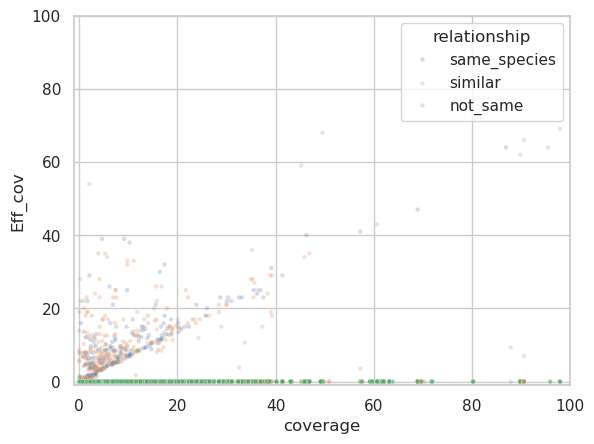

In [33]:
# sylph profile only
import polars as pl
import math

df_lst = []

for i in [0,5,10]:
    if i < 5:
            j = i + 1
    else:
        j = (i % 5) + 1

    # read coverage file
    inphared_meta = pl.read_csv(f'../figure_s9/composite_sputum/split_{j}/split_{i}_cov.txt', separator='\t')

    # load coverm data
    coverm = (
        pl.read_csv(f'uhvdb_test/split_{i}/split_{i}_profile.profile.tsv', separator='\t', ignore_errors=True)
            .with_columns([
                pl.col('Contig_name').str.split(' ').list[0].alias('contig_id')
            ])
            .filter(pl.col('Adjusted_ANI') >= 96)
    )

    # identify coverm genomes that are in inphared meta
    anicalc = (
        pl.read_csv(f'uhvdb_test/uhvdb.votu_reps_v_input.anicalc.tsv', separator='\t')
            .with_columns([
                ((pl.col('pid') * (pl.col('qcov')))/10000).alias('qani'),
                ((pl.col('pid') * (pl.col('tcov')))/10000).alias('tani')
            ])
            .with_columns([
                pl.when((pl.col('pid') >= 95) & ((pl.col('qcov') >= 85) | (pl.col('tcov') >= 85))).then(pl.lit('same_species'))
                    .when((pl.col('pid') >= 90) & ((pl.col('qcov') >= 50) | (pl.col('tcov') >= 50))).then(pl.lit('similar'))
                    .otherwise(pl.lit('not_same'))
                    .alias('relationship'),
            ])
            .join(inphared_meta, on='tname', how='right') # only keep blast results if the target is in the input genomes
            .sort('qani', descending=True)
            .group_by('qname', maintain_order=True)
            .first()
            .join(coverm, left_on='qname', right_on='contig_id', how='full')
    )

    df_lst.append(anicalc[['qname', 'tname', 'pid', 'qcov', 'tcov', 'qani', 'relationship', 'coverage', 'genome_length', 'Eff_cov', 'Adjusted_ANI']])

# create dataframe
df = pl.concat(df_lst).fill_null(0)
print("TP species:", df.filter((pl.col('relationship') == 'same_species') & (pl.col('Eff_cov') > 0)).unique('tname').shape[0])
print("TP genera:", df.filter((pl.col('relationship') == 'similar') & (pl.col('Eff_cov') > 0)).unique('tname').shape[0])
print("FP:", df.filter((pl.col('relationship') == 'not_same') & (pl.col('Eff_cov') > 0)).unique('tname').shape[0])
print("R-squared:", r2_score(df.filter((pl.col('Eff_cov') > 0))['coverage'].to_list(), df.filter((pl.col('Eff_cov') > 0))['Eff_cov'].to_list()))
print("Total species > 1x:", df.filter((pl.col('relationship') == 'same_species') & (pl.col('coverage') > 0)).unique('tname').shape[0])
print("Total genera > 1x:", df.filter((pl.col('relationship') == 'similar') & (pl.col('coverage') > 0)).unique('tname').shape[0])
# plot breadth results
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")
sns.scatterplot(data=df, x='coverage', y='Eff_cov', s=10, alpha=0.25, hue='relationship')
plt.xlim(-1, 100)
plt.ylim(-1, 100)
plt.show()